
# Lista de Exercícios #9 - k-Means

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.special import erfc

## Questão 1

In [8]:

# Questão 1 - Aplicações reais do k-Means
- Segmentação de clientes em marketing.
- Compressão de imagens (redução de cores).
- Análise de agrupamento de documentos.
- Agrupamento de sensores em redes IoT.
- Detecção de anomalias.
- Agrupamento geográfico (GPS, mapas).


## Questão 2

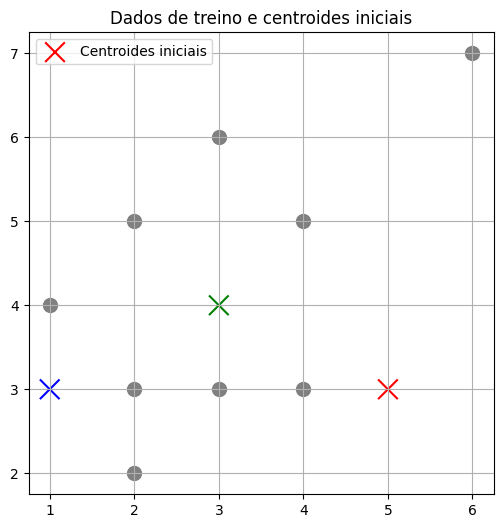

Centroid 0: (6.00, 7.00)
Centroid 1: (2.00, 3.00)
Centroid 2: (3.25, 4.75)
Número de iterações até convergência: 4


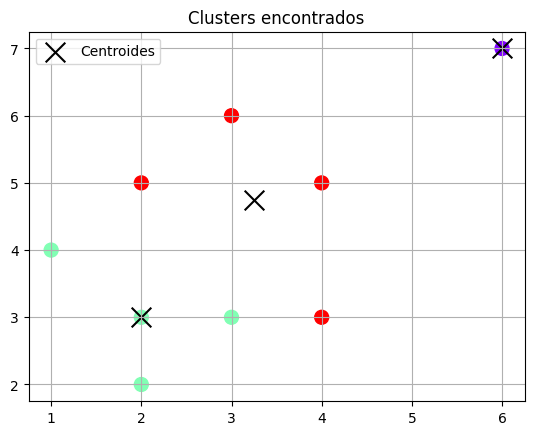

In [7]:

# Questão 2 - KMeans manual

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dados
X = np.array([[1,4],[4,3],[4,5],[3,6],[6,7],[3,3],[2,5],[2,2],[2,3]])
init_clusters = np.array([[5,3],[1,3],[3,4]])

# Plot dos dados
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=100, c='gray')
plt.scatter(init_clusters[:,0], init_clusters[:,1], c=['red','blue','green'], marker='x', s=200, label='Centroides iniciais')
plt.title('Dados de treino e centroides iniciais')
plt.legend()
plt.grid(True)
plt.show()

# Aplicando KMeans
km = KMeans(n_clusters=3, init=init_clusters, n_init=1)
km.fit(X)

# Imprimindo centroides
for i in range(3):
    print(f'Centroid {i}: ({km.cluster_centers_[i][0]:.2f}, {km.cluster_centers_[i][1]:.2f})')

print(f'Número de iterações até convergência: {km.n_iter_}')

# Plot com clusters
plt.scatter(X[:,0], X[:,1], c=km.labels_, cmap='rainbow', s=100)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], marker='x', s=200, color='black', label='Centroides')
plt.title('Clusters encontrados')
plt.legend()
plt.grid(True)
plt.show()


## Questão 3

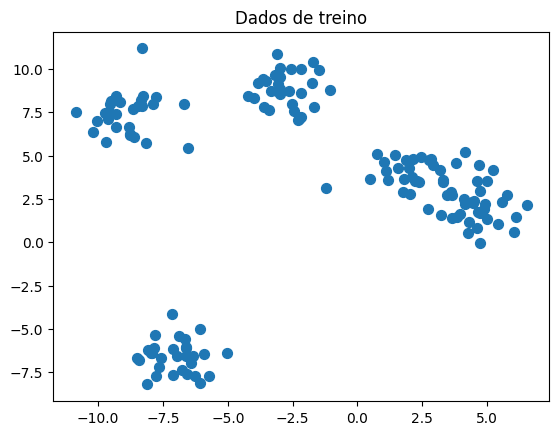

Centroid 0: (4.59, 2.07)
Centroid 1: (-8.90, 7.43)
Centroid 2: (-7.02, -6.59)
Centroid 3: (-2.76, 8.82)
Centroid 4: (2.06, 4.11)
Número de iterações até convergência: 4


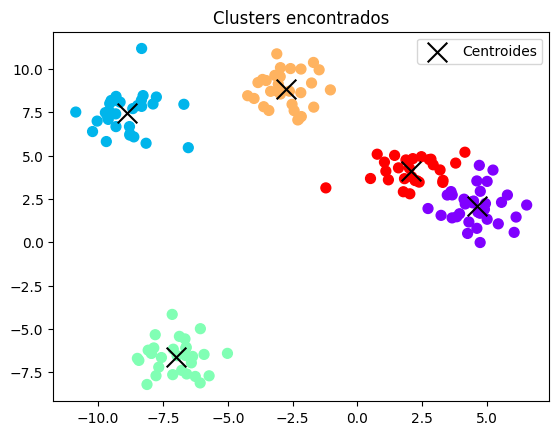

In [4]:

# Questão 3 - Clustering com make_blobs

from sklearn.datasets import make_blobs

# Dados
X, y = make_blobs(n_samples=150, n_features=2, centers=5, cluster_std=1.0, random_state=42)

# Plot dos dados
plt.scatter(X[:,0], X[:,1], s=50)
plt.title('Dados de treino')
plt.show()

# Aplicando KMeans
k = 5
km = KMeans(n_clusters=k, random_state=42)
km.fit(X)

# Imprimindo centroides
for i in range(k):
    print(f'Centroid {i}: ({km.cluster_centers_[i][0]:.2f}, {km.cluster_centers_[i][1]:.2f})')

print(f'Número de iterações até convergência: {km.n_iter_}')

# Plot dos clusters
plt.scatter(X[:,0], X[:,1], c=km.labels_, cmap='rainbow', s=50)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], marker='x', s=200, color='black', label='Centroides')
plt.title('Clusters encontrados')
plt.legend()
plt.show()


## Questão 4

Es/N0 = -2 dB -> SER = 2.44077e-01
Es/N0 = 0 dB -> SER = 1.51234e-01
Es/N0 = 2 dB -> SER = 7.34860e-02
Es/N0 = 4 dB -> SER = 2.49110e-02
Es/N0 = 6 dB -> SER = 4.74700e-03
Es/N0 = 8 dB -> SER = 3.80000e-04
Es/N0 = 10 dB -> SER = 9.00000e-06
Es/N0 = 12 dB -> SER = 0.00000e+00
Es/N0 = 14 dB -> SER = 0.00000e+00
Es/N0 = 16 dB -> SER = 0.00000e+00
Es/N0 = 18 dB -> SER = 0.00000e+00
Es/N0 = 20 dB -> SER = 0.00000e+00


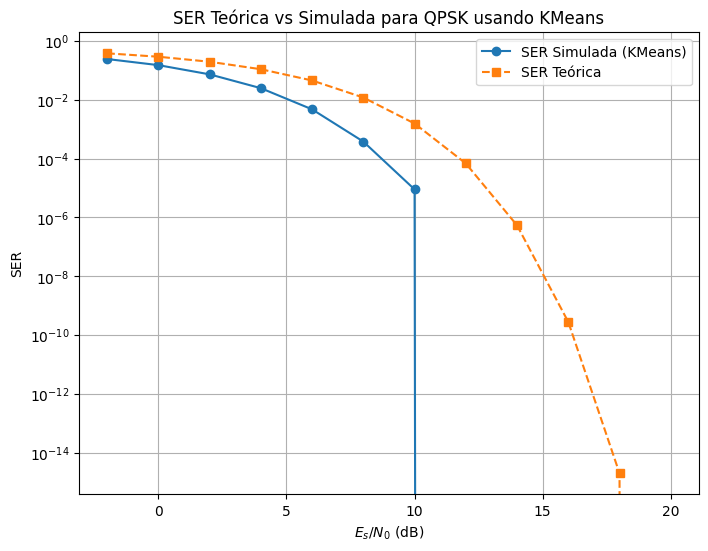

In [5]:

# Questão 4 - QPSK com KMeans

from scipy.special import erfc

N = 1000000
symbols_ref = np.array([1+1j, 1-1j, -1+1j, -1-1j])
symbols = np.random.choice(symbols_ref, N)

EsN0_dB = np.arange(-2, 22, 2)
SER_sim = []
SER_theory = []

for EsN0 in EsN0_dB:
    EsN0_linear = 10**(EsN0/10)
    noise_std = np.sqrt(1/(2*EsN0_linear))

    noise = noise_std * (np.random.randn(N) + 1j * np.random.randn(N))
    rx = symbols + noise

    X = np.column_stack((rx.real, rx.imag))
    kmeans = KMeans(n_clusters=4, n_init=1, random_state=42).fit(X)

    centroids = kmeans.cluster_centers_[:, 0] + 1j * kmeans.cluster_centers_[:, 1]
    labels = kmeans.labels_

    label_to_symbol = {}
    for i, centroid in enumerate(centroids):
        dists = np.abs(centroid - symbols_ref)
        closest_symbol = symbols_ref[np.argmin(dists)]
        label_to_symbol[i] = closest_symbol

    decoded_symbols = np.array([label_to_symbol[label] for label in labels])

    errors = np.sum(decoded_symbols != symbols)
    SER = errors / N
    SER_sim.append(SER)

    ser_theory = 1 - (1 - erfc(np.sqrt(EsN0_linear)/np.sqrt(2))/2)**2
    SER_theory.append(ser_theory)

    print(f'Es/N0 = {EsN0} dB -> SER = {SER:.5e}')

# Plot
plt.figure(figsize=(8,6))
plt.semilogy(EsN0_dB, SER_sim, 'o-', label='SER Simulada (KMeans)')
plt.semilogy(EsN0_dB, SER_theory, 's--', label='SER Teórica')
plt.xlabel('$E_s/N_0$ (dB)')
plt.ylabel('SER')
plt.title('SER Teórica vs Simulada para QPSK usando KMeans')
plt.grid(True, which='both')
plt.legend()
plt.show()


## Questão 5

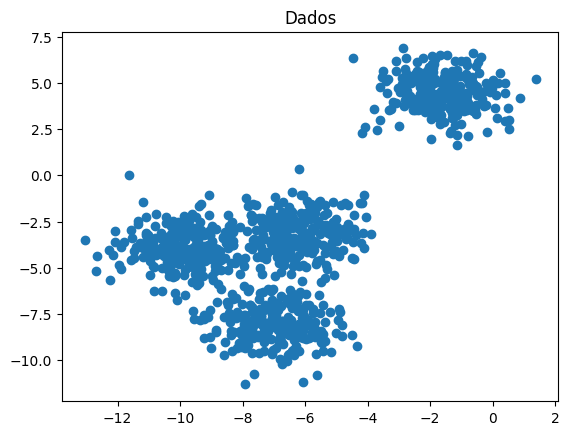

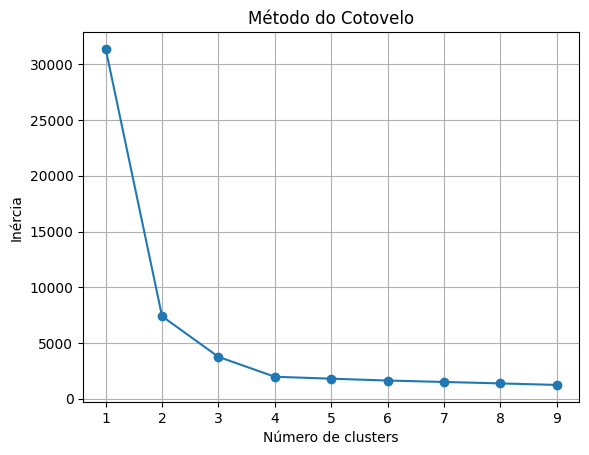

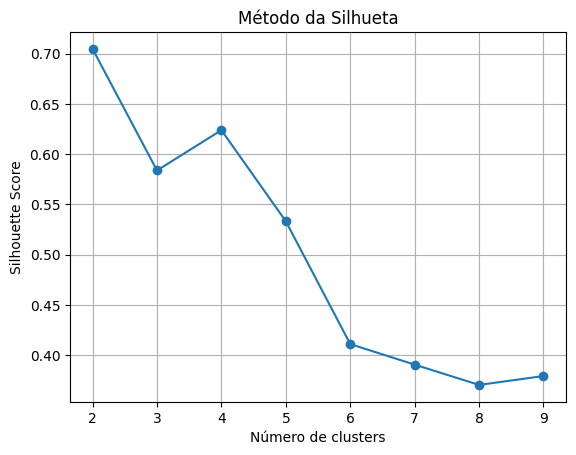

In [8]:

# Questão 5 - Escolha de K (Elbow e Silhouette)

from sklearn.metrics import silhouette_score

X, y = make_blobs(n_samples=1000, n_features=2, centers=4,
                   cluster_std=1, center_box=(-10.0, 10.0),
                   shuffle=True, random_state=1)

plt.scatter(X[:,0], X[:,1])
plt.title('Dados')
plt.show()

# Método do cotovelo
inertias = []
k_range = range(1,10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, 'o-')
plt.xlabel('Número de clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid()
plt.show()

# Método da Silhueta
silhouette_scores = []
k_range = range(2,10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(k_range, silhouette_scores, 'o-')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Método da Silhueta')
plt.grid()
plt.show()
